<a href="https://colab.research.google.com/github/martalgc26/procesos_estocasticos/blob/main/MCs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#**SIMULAR Y VISUALIZAR MCs**

In [4]:
# Importamos los módulos necesarios para la implementación

import numpy as np #para manejar los datos
import matplotlib.pyplot as plt #para graficar
import math

##**1. Simular la trayectoria de una MC**



Vamos a definir una función que nos permita generar trayectorias de una Cadena de Markov (MC). Primero la implementaremos de la forma más intuitiva, usando dos bucles for y posteriormente usaremos el broadcasting de Numpy para eliminar uno de los bucles y hacerlo así más eficiente.

**Sobre la notación**:

En clases de teoría hemos denotado los $m$ estados de una MC como $\{1, 2, \dots, m\}$.Sin embargo, dado que en Python y NumPy la indexación de los arrays empieza en $0$ utilizaremos la notación $\{0, 1, \dots, m-1\}$. Una vez que el algoritmo termine de generar la trayectoria, simplemente le sumaremos $+1$ a los resultados finales para que la función devuelva los estados en la notación original $\{1, 2, \dots, m\}$.

Esto nos permite mantener un código mucho más limpio y evitar errores con los índices.

In [5]:
def simular_trayectorias(P, pi_sup_1, n_samples, n_steps):

  """
  Función para simular trayectorias de una MC.

  Input:
    P: np.array (m,m)
       Matriz de transición de la MC dnd m es el numero de estados. P[i,j] es la probabilidad de pasar del estado i al j
    pi_sup_1: np.array (m,)
       Distribución inicial de la MC. Probabilidades de empezar en cada estado.
    n_samples:int
       Número de trayectorias a simular.
    n_steps: int
       Número de pasos de la simulación.

  Output:
    trayectorias: np.array(n_samples, n_steps)
      Muestras de las trayectorias de las MC simuladas.
  """

  # Guardamos el valor de m (número de estados)
  m = P.shape[0]

  # Creamos una matriz de ceros de tamaño (n_samples, n_steps) para guardar las trayectorias de cada simulación
  trayectorias = np.zeros((n_samples,n_steps), dtype=int) #usamos 'dtype=int' xq simulamos MC discreta

  # Incializamos el valor del estado escogido en n=0 para todas las trayectorias
  # 'np.random.choice' elige un estado del 0 al m-1 para 'n_samples' muestras
  # usando para la eleccion la distribucion inicial dada 'p=pi_sup_1'
  trayectorias[:,0] = np.random.choice(m,size=n_samples, p=pi_sup_1)

  # Generamos el resto de valores de la trayectoria para todos los pasos
  #(requiere de un proceso iterativo por la propiedad de Markov)
  for step in range(1, n_steps):

    # Iteramos sobre cada trayectoria para calcular su siguiente estado teniendo en cuenta el estado actual
    for sample in range(n_samples):

      # Obtengo en qué estado se quedó la trayectoria en el paso anterior
      estado_actual = trayectorias[sample, step-1] #int

      # Usamos 'np.random.choice' para calcular el nuevo estado usando las probabilidades
      # de la fila correspondiente al 'estado_actual' en la matriz de transicion P
      trayectorias[sample, step] = np.random.choice(m, p=P[estado_actual,:])

  return trayectorias+1

A continuación vamos a hacer una versión más eficiente de esta función eliminando uno de los bucles `for` (concretamente, el que recorre `n_samples`) que sí es conceptualmente paralelizable ya que el que recorre `n_steps`, no se puede eliminar porque la construcción de la cadena es un proceso inherentemente iterativo.

Para lograr esta paralelización, usaremos el broadcasting de la libreria Numpy. Para ello, dividiremos el bucle en tres pasos:

1. Generamos de una vez un vector de tamaño `(n_samples,1)` con números aleatorios entre 0 y 1 de forma uniforme usando `np.random.rand`.
2. Extraemos de forma conjunta las probabilidades de transición de todas las muestras según el estado en el que se encontraban en el paso anterior y les aplicamos la suma acumulada por filas (`np.cumsum(..., axis=1)`). De esta forma tranformamos probabilidades individuales en filas con tramos entre 0 y 1 proporcionales a la probabilidad de transición hacia cada estado.
3. Usando el broadcasting de Numpy creamos un array de booleanos `aleatorios < P_acumulada` que nos indica cual es el siguiente estado de la trayectoria dependiendo del tramo en el que se hayaa quedado el número aleatorio. Aplicamos `argmax()`con `axis=1` para que trabaje por filas y quede con el índice del estado que contenga el primer valor `True`.

In [6]:
import numpy as np

def simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps):
  """
  Función para simular trayectorias de una MC de forma optimizada.

  Input:
     P: np.array (m,m)
        Matriz de transición de la MC dnd m es el número de estados. P[i,j] es la probabilidad de pasar del estado i al j
     pi_sup_1: np.array (m,)
        Distribución inicial de la MC. Probabilidades de empezar en cada estado.
     n_samples: int
        Número de trayectorias a simular.
     n_steps: int
        Número de pasos de la simulación.

  Output:
     trayectorias: np.array (n_samples, n_steps)
        Muestras de las trayectorias de las MC simuladas.
  """

  # Guardamos el valor de m (número de estados)
  m = P.shape[0]

  # Creamos una matriz de ceros de tamaño (n_samples, n_steps) para guardar las trayectorias de cada simulación
  trayectorias = np.zeros((n_samples, n_steps), dtype=int) # usamos 'dtype=int' xq simulamos MC discreta

  # Inicializamos el valor del estado escogido en n=0 para todas las trayectorias
  # 'np.random.choice' elige un estado del 0 al m-1 para 'n_samples' muestras
  # usando para la elección la distribución inicial dada 'p=pi_sup_1'
  trayectorias[:, 0] = np.random.choice(m, size=n_samples, p=pi_sup_1)

  # Generamos el resto de valores de la trayectoria para todos los pasos
  # (requiere de un proceso iterativo por la propiedad de Markov)
  for step in range(1, n_steps):

    # Generamos un número aleatorio entre 0 y 1 de manera uniforme para cada trayectoria
    # Obtenemos un array de tamaño (n_samples, 1) en columna para aplicar posteriormente broadcasting
    u = np.random.rand(n_samples, 1)

    # Extraemos conjuntamente las filas de la matriz de transición P correspondientes al estado anterior de todas las muestras
    # 'trayectorias[:, step-1]' nos da el vector con los estados anteriores
    # Usamos 'np.cumsum(..., axis=1)' para calcular las probabilidades acumuladas por filas (de izq a dcha)
    P_acumulada = np.cumsum(P[trayectorias[:, step-1], :], axis=1)

    # Evaluamos la condición 'u < P_acumulada' aprovechando el broadcasting para comparar la columna 'u' con la matriz 'P_acumulada'
    # Se genera una matriz de booleanos de tamaño (n_samples, m)
    # Usamos 'np.argmax(..., axis=1)' para buscar el índice del primer 'True' de cada fila (ya que en booleanos el 'True' es el valor máximo)
    trayectorias[:, step] = np.argmax(u < P_acumulada, axis=1)

  # Al finalizar, sumamos +1 a toda la matriz para transformar la nomenclatura interna {0, 1, ..., m-1}
  # a la nomenclatura que espera el usuario {1, 2, ..., m}
  return trayectorias + 1

### **Ejecución comparando eficiencia**

Una vez implementadas ambas opciones, evaluamos la eficiencia de ambas funciones. Para ello, usamos el comando %timeit, el cual realiza la simulación varias veces y calcula un resumen estadístico del tiempo de ejecución (media y desviación típica sobre diferentes pruebas). Además añadimos los parámetros -o para que dichos resultados se guarden en una variable y poder calcular la mejora de eficiencia de forma automática,y el parámetro -q (quiet) para silenciar los resúmenes automáticos que genera Jupyter por defecto y mostrar en pantalla los tiempos al finalizar.

In [7]:
# Definimos los parámetros iniciales para ambas simulaciones
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 1000
n_steps = 50

# Probamos la función con dos bucles
print("Ejecutando primera función...")
output_lento = %timeit -q -o simular_trayectorias(P, pi_sup_1, n_samples, n_steps)

# Probamos la versión eficiente
print("Ejecutando segunda función...")
output_eficiente = %timeit -q -o simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)

# Obtenemos el tiempo promedio de cada salida (en segundos) usando el método '.average'
tiempo_lento = output_lento.average
tiempo_eficiente = output_eficiente.average

# Calculamos el factor de mejora dividiendo ambos tiempos promedio
mejora = tiempo_lento / tiempo_eficiente

# Mostramos los resultados finales formateados por pantalla
print("\n--- COMPARATIVA DE EFICIENCIA ---")
print(f"Tiempo medio de la función con doble bucle: {tiempo_lento*1000:.2f} milisegundos.")
print(f"Tiempo medio de la función eficiente:   {tiempo_eficiente*1000:.2f} milisegundos.")
print(f"La función optimizada es {mejora:.1f} veces más rápida")

Ejecutando primera función...
Ejecutando segunda función...

--- COMPARATIVA DE EFICIENCIA ---
Tiempo medio de la función con doble bucle: 1488.87 milisegundos.
Tiempo medio de la función eficiente:   5.00 milisegundos.
La función optimizada es 297.6 veces más rápida


### **Visualización de trayectorias**

A continuación, vamos a visualizar gráficamente una MC simulando 6 trayectorias aleatorias durante 50 pasos.

Dado que estamos simulando una MC en tiempo discreto y espacio de estados discretos, ocurre frecuentemente que varias trayectorias coinciden en el mismo estado en un momento dado solapándose así las visualizaciones. Para solucionar este problema visual, aplicaremos un pequeño desplazamiento o "épsilon" proporcional al índice de cada muestra que serapará de forma casi imperceptible las líneas en vertical en la gráfica sin alterar el resultado final.

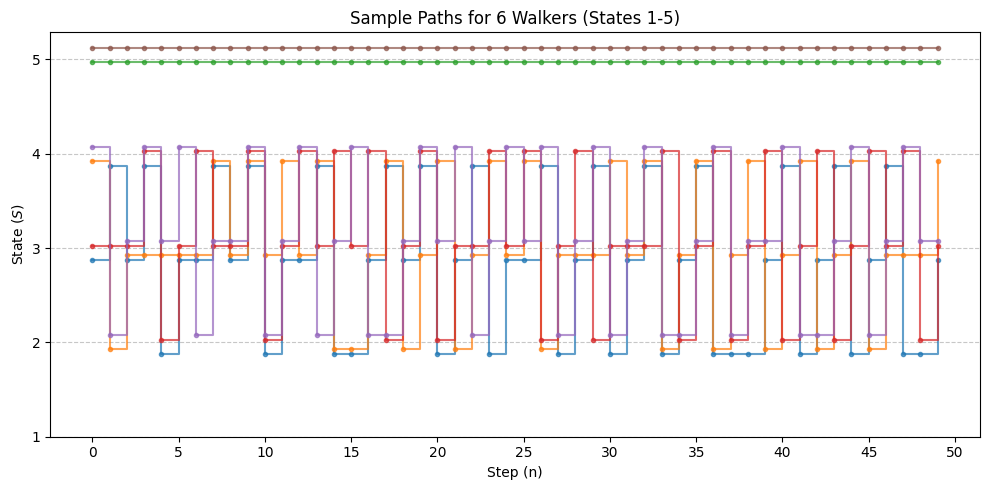

In [8]:
# Definimos los parámetros inciales para la simulación
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_samples = 6
n_steps = 50

# Obtenemos las trayectorias con la función eficiente
trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps)

# Definimos un épsilon pequeño para evitar el solapamiento visual de las trayectorias
epsilon = 0.05

# Posición relativa respecto del centro
desplazamiento = (n_samples - 1) / 2

# genramos una figura principal donde incrustar el gráfico
plt.figure(figsize=(10, 5))

for i in range(n_samples):

  # Generamos los valores del eje de abscisas
  abscisas_x = np.arange(n_steps)

  # Extraemos cada trayectoria y le aplicamos el desplazamiento de épsilon de forma simétrica
  ordenadas_y = trayectorias[i, :] + (i - desplazamiento ) * epsilon

  plt.step(abscisas_x, ordenadas_y, where='post', alpha=0.7, marker='o', markersize=3)

m = P.shape[0]
plt.yticks(np.arange(1, m+1))
plt.xticks(np.arange(0, n_steps + 1, 5))
plt.xlabel("Step (n)")
plt.ylabel(r"State ($S$)")
plt.title(f"Sample Paths for {n_samples} Walkers (States 1-5)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

##**2. Distribución marginal de una MC**

A continuación, implementamos una función para obtener la distribución marginal de la Cadena de Markov en cualquier instante de tiempo discreto $n$.

Por la teoría vista en clase, si conocemos la distribución inicial del proceso en el primer paso, $\pi^{(1)}$, la distribución de probabilidad de los estados en el instante $n$ se calcula como

$$\pi^{(n)} = \pi^{(1)} P^{n-1}$$

In [9]:
def obtener_marginal(P, pi_sup_1, n):
  """
  Función para calcular la distribución marginal de una MC en cierto instante.

  Input:
     P: np.array (m,m)
        Matriz de transición de la MC dnd m es el número de estados. P[i,j] es la probabilidad de pasar del estado i al j
     pi_sup_1: np.array (m,)
        Distribución inicial de la MC. Probabilidades de empezar en cada estado.
     n: int
        Instante de tiempo en el que se quiere calcular la distribución marginal.

  Output:
     marginal: np.array (m,)
        Distribución marginal en el instante n (es decir, lo que hemos llamado pi^{(n)}).
  """

  # Calculamos la distribución marginal en el instante n en base al producto matricial
  # 'np.linalg.matrix_power' eleva de forma conjunta la matriz P a la potencia 'n-1'
  # Usamos el operador '@' xq hace el producto matricial entre el vector fila 'pi_sup_1' y 'P_potencia'
  marginal = pi_sup_1 @  np.linalg.matrix_power(P, n-1)

  return marginal

Utiliza la función anterior para visualizar empíricamente que la distribución marginal de nuestra MC converge a diferentes distribuciones si empezamos en distribuciones iniciales diferentes. Es decir, reproduce las imágenes de las diapositivas 61 y 63.

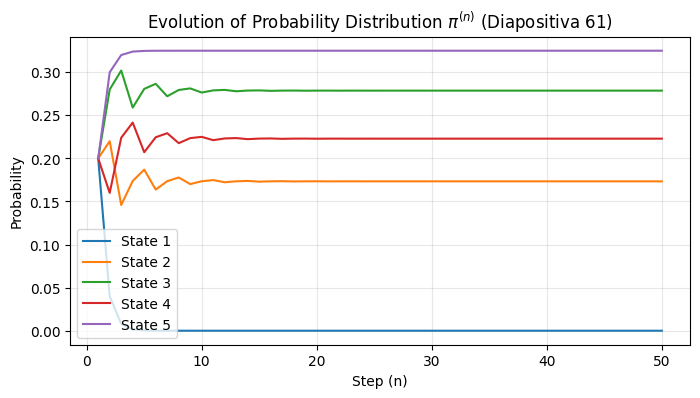

In [10]:
# Definimos los parámetros iniciales para la simulación
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])

pi_sup_1 = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
n_pasos = 50
m = P.shape[0]

# Creamos un array inicial de ceros (m,n_pasos) para guardar las marginales  de cada paso
marginales = np.zeros((m, n_pasos))

for i in range(n_pasos):
  marginales[:, i] = obtener_marginal(P, pi_sup_1, n=i+1) # i+1 porque el bucle empieza en 0

plt.figure(figsize=(8, 4))
for j in range(m):
    # Graficamos la evolución de la probabilidad de cada estado j
    plt.plot(np.arange(1, n_pasos + 1), marginales[j, :], label=f"State {j+1}")

plt.xlabel("Step (n)")
plt.ylabel("Probability")
plt.title(r"Evolution of Probability Distribution $\pi^{(n)}$ (Diapositiva 61)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

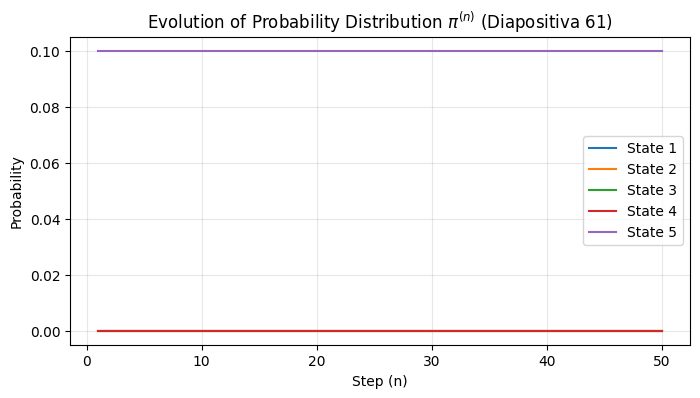

In [11]:
# Definimos los parámetros iniciales para la simulación
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])

pi_sup_1 = np.array([0.0, 0.0, 0.0, 0.0, 0.1])
n_pasos = 50
m = P.shape[0]

# Creamos un array inicial de ceros (m,n_pasos) para guardar las marginales  de cada paso
marginales = np.zeros((m, n_pasos))

for i in range(n_pasos):
  marginales[:, i] = obtener_marginal(P, pi_sup_1, n=i+1) # i+1 porque el bucle empieza en 0

plt.figure(figsize=(8, 4))
for j in range(m):
    # Graficamos la evolución de la probabilidad de cada estado j
    plt.plot(np.arange(1, n_pasos + 1), marginales[j, :], label=f"State {j+1}")

plt.xlabel("Step (n)")
plt.ylabel("Probability")
plt.title(r"Evolution of Probability Distribution $\pi^{(n)}$ (Diapositiva 61)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

##**3. Diagrama de transición de estados**

Vamos a definir una función para dibujar el diagrama de transición de estados de una MC. Como hemos visto, esta es una de las formas más habituales de visualizar una MC.

Trata de entender la siguiente función (al menos sus argumentos de entrada y su funcionamiento general, hay detalles sobre los "edge_labels" que son menos relevantes para nosotros).

In [12]:
import networkx as nx

def dibujar_diagrama_transicion(P, states):

  # Use DiGraph (Directed Graph)
  G = nx.DiGraph()
  for i in range(len(P)):
      for j in range(len(P)):
          if P[i, j] > 0:
              G.add_edge(states[i], states[j], weight=P[i, j])

  # Define layout
  pos = nx.circular_layout(G)

  # Create the plot
  plt.figure(figsize=(8, 6))

  # Draw nodes and edges
  # 'connectionstyle' curves the edges to prevent overlap on bidirectional paths
  nx.draw(G, pos, with_labels=True, node_color='lightblue',
          node_size=800, arrowsize=20,
          connectionstyle='arc3, rad = 0.1')

  # 2. Add the weights as labels
  edge_labels = nx.get_edge_attributes(G, 'weight')

  # Optional: Format labels to look cleaner (e.g., 0.5 instead of 0.500000)
  formatted_edge_labels = {k: f"{v:g}" for k, v in edge_labels.items()}

  nx.draw_networkx_edge_labels(G, pos, edge_labels=formatted_edge_labels, label_pos=0.2)

  plt.title("State Transition Diagram with Weights")
  plt.show()

Vamos a probar la función anterior dibujando el diagrama de transición de estados de nuestra MC basado en la matriz de transición que se presentó en la diapositiva 27.

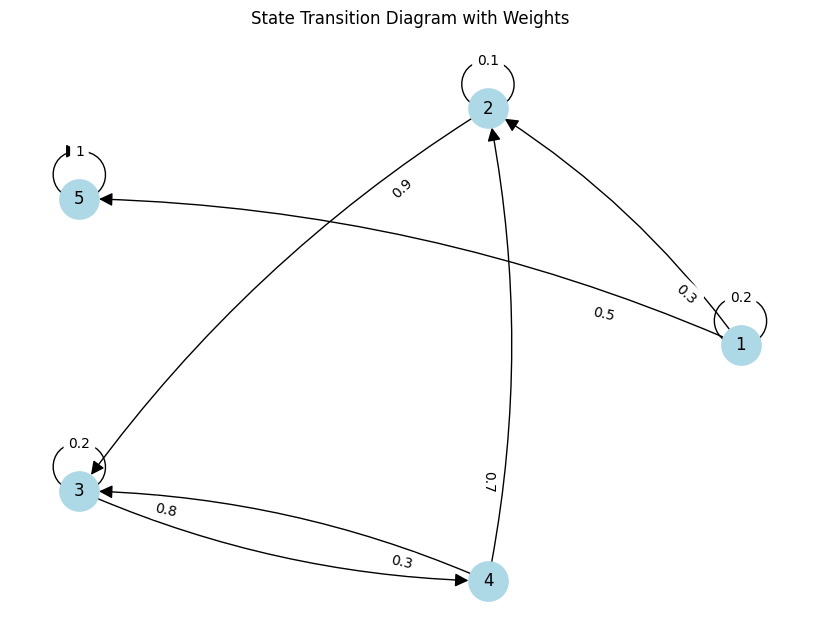

In [13]:
# Definimos los parámetros necesarios para la función
P = np.array([
    [0.2, 0.3, 0.0, 0.0, 0.5],
    [0.0, 0.1, 0.9, 0.0, 0.0],
    [0.0, 0.0, 0.2, 0.8, 0.0],
    [0.0, 0.7, 0.3, 0.0, 0.0],
    [0.0, 0.0, 0.0, 0.0, 1.0]
])
m = P.shape[0]
estados = np.arange(1, m+1) # creamos estados {1,..,m}

# Dibjamos el diagrama de estados con la función dada
dibujar_diagrama_transicion(P, estados)

##**4. Teorema de convergencia de MCs**


En esta sección vamos a ilustrar tres ideas que hemos estudiado en el contexto del teorema de convergencia de MCs:

1. Una MC es unicadenal y aperiódica $\iff$ la distribución marginal converge siempre a la misma distribución (independientemente de la distribución inicial).
2. Una MC es aperiódica $\iff$ la distribución marginal converge siempre (aunque el límite puede depender de la distribución inicial).
3. Para MCs en las hipótesis del teorema de convergencia de MCs, la distribución empírica de proporciones del estado $i$-ésimo, lo que habíamos llamado $p_i(n_{samples}, n_{steps})$, converge a la componente $i$-ésima de la distribución estacionaria cuando incrementamos $n_{samples}, n_{steps}$.

### **Visualización de evolución marginal de MC**

Definimos una función que nos permita visualizar la evolución de la distribución marginal de una MC de manera más eficiencte que en el anterior apartado usando:

$$\pi^{(n)} = \pi^{(n-1)}P$$

In [14]:
def visualizar_evolucion_marginal(P, pi_sup_1, n_steps):
  """
  Función para visualizar la evolución de la distribución marginal para una MC.

  Input:
     P: np.array (m,m)
        Matriz de transición de la MC dnd m es el número de estados. P[i,j] es la probabilidad de pasar del estado i al j
     pi_sup_1: np.array (m,)
        Distribución inicial de la MC. Probabilidades de empezar en cada estado.
     n_steps: int
        Instante de tiempo hasta el que se quiere visualizar.

  Output:
     La función no devuelve nada, solo muestra un gráfico.
  """

  # Guardamos el valor de m (número de estados)
  m = P.shape[0]

  # Creamos una matriz de ceros de tamaño (m, n_steps) para guardar las marginales de cada paso
  marginales = np.zeros((m, n_steps))

  # Inicializamos la primera columna con la distribución inicial en el paso n=1
  marginales[:, 0] = pi_sup_1

  # Rellenamos el resto de pasos multiplicando el vector del paso anterior por P
  # (es producto matricial --> usamos @)
  for step in range(1, n_steps):
      marginales[:, step] = marginales[:, step-1] @ P


  plt.figure(figsize=(8, 4))

  # Dibujamos la evolución de la probabilidad para cada estado a lo largo del tiempo
  for j in range(m):
      plt.plot(np.arange(1, n_steps + 1), marginales[j, :], label=f"State {j+1}")

  # Configuramos las etiquetas y formato del gráfico
  plt.xlabel("Step (n)")
  plt.ylabel("Probability")
  plt.title(r"Evolution of Probability Distribution $\pi^{(n)}$")
  plt.legend()
  plt.grid(alpha=0.3)
  plt.show()

### **Comprobación empírica de 1**

Según el **Teorema de convergencia para MCs unicadenales**, una cadena de Markov sobre un espacio de estados finito $S=\{1,\dots,m\}$ y con matriz de transición $P$, las siguientes dos afirmaciones son estrictamente equivalentes:
1. La distribución marginal de la MC converge a una única distribución estacionaria $\pi$, es decir, $\lim_{n \to \infty} \pi^{(n)} = \pi$ para cualquier distribución inicial $\pi^{(1)}$.  
2. La cadena es unicadenal y aperiódica.

Para demostrar de forma empírica esta equivalencia, consideraremos la siguiente matriz de transición y dibujamos su diagrama.

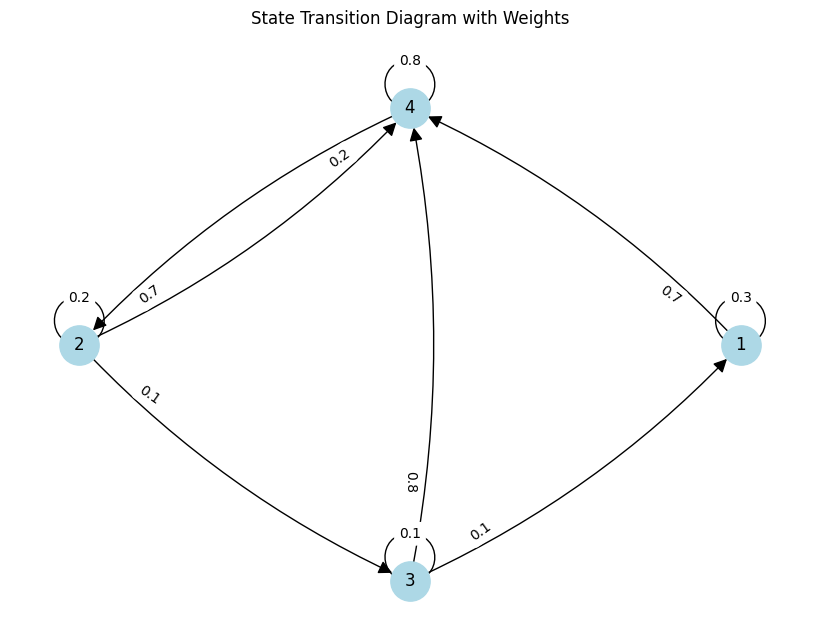

In [15]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
dibujar_diagrama_transicion(P, [1,2,3,4])

Como podremos comprobar al visualizar su diagrama, esta cadena cumple con ambas condiciones:
* **Es unicadenal (irreducible):** todos los estados se comunican entre sí formando una única clase cerrada de estados recurrentes.
* **Es aperiódica:** como las probabilidades son todasno nulas en la diagonal principal de la matriz ($p_{ii} > 0$), sabemos que hay bucles en todos los estados, luego todos son aperiódicos y la cadena en genral también los es.

Luego se cumplen las condiciones necesarias para poder aplicar el teorema.

Para comprobar que la marginal de la MC converge a una única distribución estacionaria $\pi$ para cualquier distribución inicial $\pi^{(1)}$ de forma empírica y computacional:
1. Generamos una distribución inicial de forma aleatoria válida mediante una distribución Uniforme $\mathcal{U}(0,1)$  normalizada
2. Vemos la evolución de la distribución marginal a lo largo de los primeros $50$ pasos de tiempo e
3. Imprimimos el valor de la marginal con $n=50$ varias veces con distintas distribuciones iniciales aleatirias y vemos que se obtiene el mismo resultado en todos los casos.

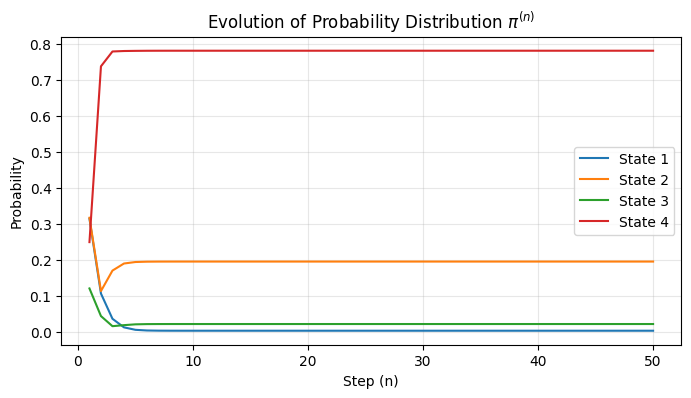

Limite ejecución [1]:  [0.00309598 0.19504644 0.02167183 0.78018576]
Limite ejecución [2]:  [0.00309598 0.19504644 0.02167183 0.78018576]
Limite ejecución [3]:  [0.00309598 0.19504644 0.02167183 0.78018576]
Limite ejecución [4]:  [0.00309598 0.19504644 0.02167183 0.78018576]
Limite ejecución [5]:  [0.00309598 0.19504644 0.02167183 0.78018576]


In [16]:
# Definimos los parámetros iniciales fijos
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
num_steps = 50

# Réllena las dos siguientes líneas para generar un pi_sup_1 aleatorio válido. Una idea es generar cada componente de una U(0,1) y luego normalizar para que las componentes sumen 1.

# Guardamos el valor de m (número de estados)
m = P.shape[0]

# Generamos un pi_sup_1 aleatorio válido
# Generamos cada componente siguiendo una distribución uniforme U(0,1)
pi_sup_1 = np.random.uniform(0, 1, m)

# Normalizamos el vector para que sus componentes sumen 1 usando el broadcasting de Numpy
pi_sup_1 = pi_sup_1 / np.sum(pi_sup_1)

# Visualizamos las marginales de la MC
visualizar_evolucion_marginal(P, pi_sup_1, num_steps)


# Imprimimos sus valores (al ejecutarlo varias veces sale el mismo resultado para distintos
# pi_sup_1 distintos)

num_ejecuciones = 5

for i in range(num_ejecuciones):
  pi_sup_1 = np.random.uniform(0, 1, m)
  pi_sup_1 = pi_sup_1 / np.sum(pi_sup_1)
  print(rf"Limite ejecución [{i+1}]: ", obtener_marginal(P, pi_sup_1, num_steps))

Cuando hicimos un esbozo de demostración del teorema de convergencia de MCs, (diapositivas 89 y 90), vimos que la sucesión de matrices $\{P^n\}_n$ convergía a una matriz en la que todas las filas eran iguales (y coincidían con la única distribución estacionaria).

Vamos a visualizar varios términos de esta sucesión para comprobar empíricamente que esto sucede.

Primero vamos a ver cómo podemos **representar visualmente una matriz**. Una manera habitual es mediante un "heatmap" (mapa de calor).

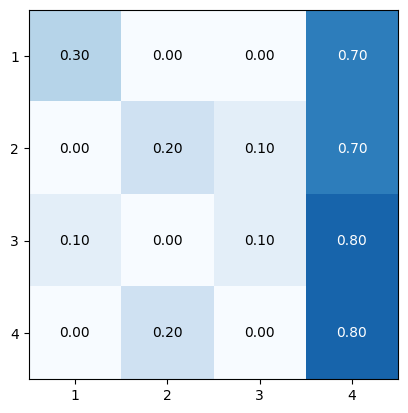

In [17]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])

# Dibujar el heatmap
plt.imshow(P, cmap='Blues', vmin=0, vmax=1)

# Añadir texto con los valores explícitos
m = P.shape[0]
for i in range(m):       # rows
        for j in range(m):   # columns
            value = P[i, j]
            # Dynamically change text color based on cell brightness for readability
            text_color = "white" if value > 0.5 else "black"
            # Add text (note: text coordinates are (column, row) -> (j, i))
            plt.text(j, i, f"{value:.2f}",
                    ha="center", va="center",
                    color=text_color, fontsize=10)

plt.xticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
plt.yticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))

plt.show()

Al ver la evolución de $\{P^n\}_n$ en tres instantes: $n=1,2,10$ comprobamos que efectivamente esta sucesión parece estabilizarse en una matriz en las que todas las filas son la misma. Además coincide con la distribución estacionaria que obtuvimos empíricamente dos celdas más arriba, cuando vimos dónde parecía estabilizarse la marginal de la MC en el paso $50$.

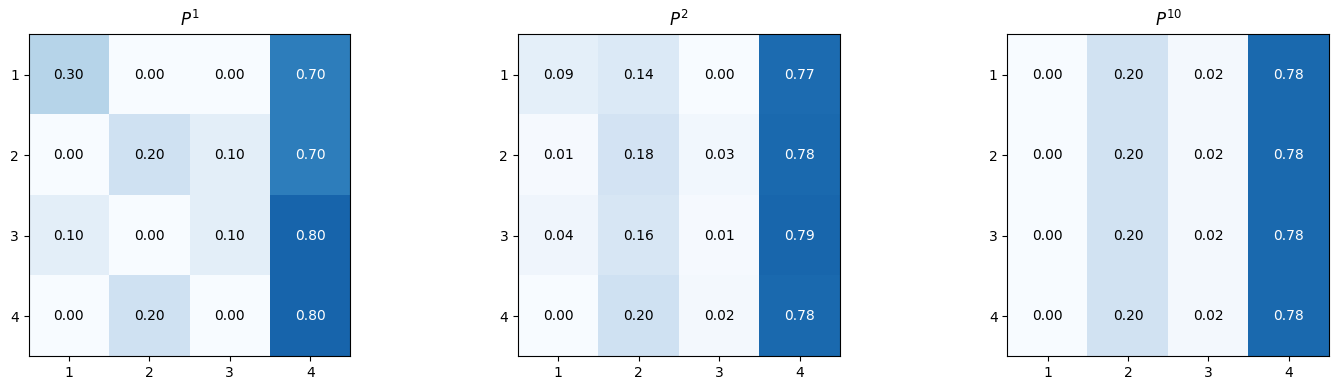

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
steps_to_show = [1, 2, 10]

for ax, n in zip(axes, steps_to_show):

    # Calculamos de forma eficiente la potencia n-ésima de la matriz de transición P
    Pn = np.linalg.matrix_power(P, n)

    im = ax.imshow(Pn, cmap='Blues', vmin=0, vmax=1)
    ax.set_title(f"$P^{{{n}}}$")
    ax.set_xticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
    ax.set_yticks(np.arange(P.shape[0]), labels=1+np.arange(P.shape[0]))
    # Loop over data dimensions and create text annotations
    for i in range(Pn.shape[0]):       # rows
        for j in range(Pn.shape[1]):   # columns
            value = Pn[i, j]

            # Dynamically change text color based on cell brightness for readability
            text_color = "white" if value > 0.5 else "black"

            # Add text (note: text coordinates are (column, row) -> (j, i))
            ax.text(j, i, f"{value:.2f}",
                    ha="center", va="center",
                    color=text_color, fontsize=10)

plt.tight_layout()
plt.show()

###**Comprobación empírica de 2**

Sea $\{X_n\}_n$ una cadena de Markov sobre un espacio de estados finito $S = \{1, \dots, m\}$, con matriz de transición $P$. Son equivalentes:

1. La marginal de la MC converge para cualquier distribución inicial $\pi^{(1)}$ (aunque el límite final pueda diferir en función de $\pi^{(1)}$).
2. La cadena es **aperiódica**.

Para demostrar de forma empírica esta equivalencia, consideraremos la siguiente matriz de transición y dibujamos su diagrama.

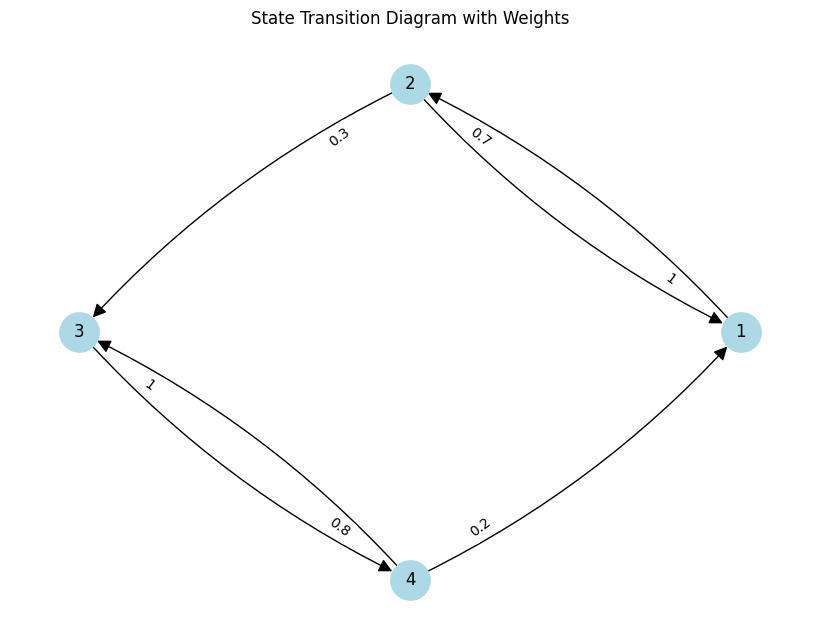

In [19]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
dibujar_diagrama_transicion(P, np.arange(1,P.shape[0]+1))

En las siguientes tres celdas se usa la función "visualizar_evolucion_marginal" para ver la evolución de la marginal para tres distribuciones iniciales diferentes. Además, se imprime por pantalla la marginal en el paso $50$:

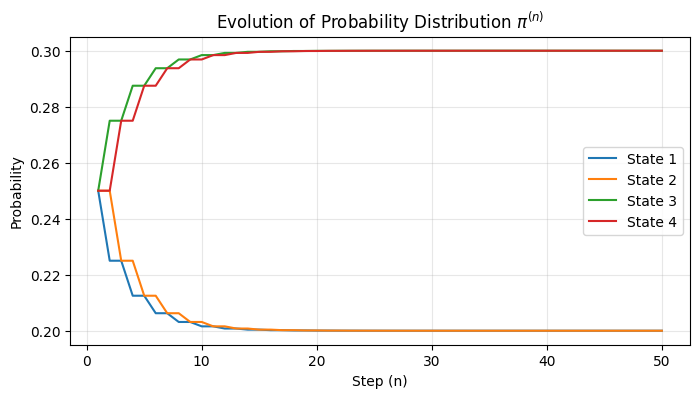

[0.2 0.2 0.3 0.3]


In [20]:
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

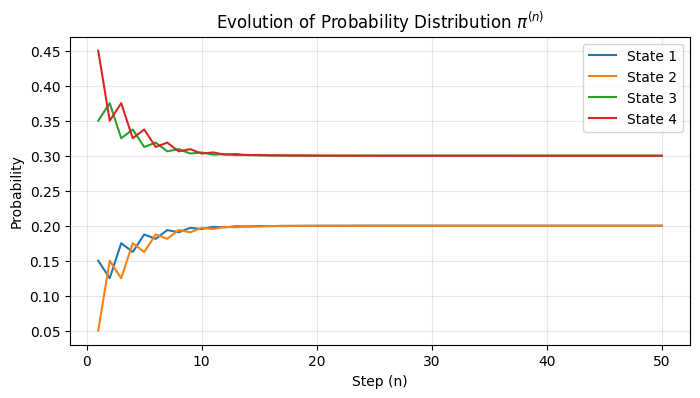

[0.2 0.2 0.3 0.3]


In [21]:
pi_sup_1 = np.array([0.15, 0.05, 0.35, 0.45])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

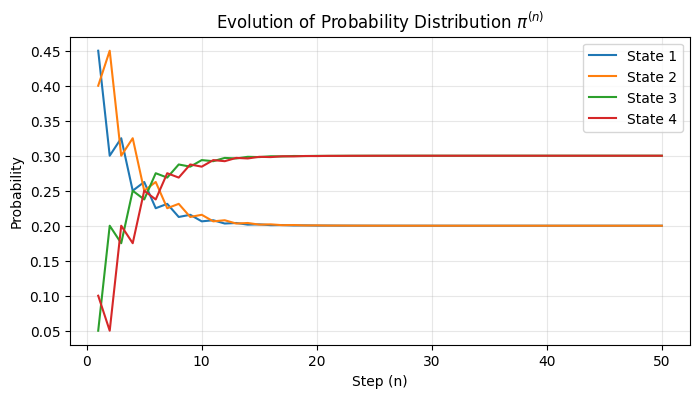

[0.20000001 0.20000001 0.29999999 0.29999999]


In [22]:
pi_sup_1 = np.array([0.45, 0.40, 0.05, 0.10])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

A primera vista, el hecho de que la distribución marginal parezca converger al vector $[0.2, 0.2, 0.3, 0.3]$ bajo tres condiciones iniciales distintas podría hacernos pensar que existe una contradicción en el teorema estudiado.

Sin embargo es fácil comprobar que si se cumple pues la MC de la que partimos no es aperiódica (todos sus estados tienen periodo $d=2$)

Para demostrar empíricamente que no existe contradicción hemos elegido la distribución inicial
 $$\pi^{(1)} = [1, 0, 0, 0]$$
 que hace que se manifieste el comportamiento periódico de la cadena.

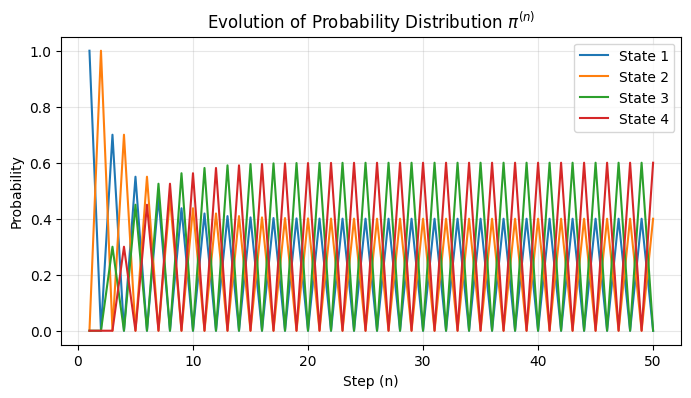

[0.         0.40000004 0.         0.59999996]


In [23]:
pi_sup_1 = np.array([1.0, 0.0, 0.0, 0.0])
visualizar_evolucion_marginal(P, pi_sup_1, 50)
print(obtener_marginal(P, pi_sup_1, 50) )

###**Comprobación empírica de 3**

Vamos a demostrar que:
**$$\lim_{\substack{n_{samples} \to \infty \\ n_{steps} \to \infty}} p_i(n_{samples}, n_{steps}) = \pi_i$$**

Definimos una función que dada la MC y dados los valores de $n_{samples}$ y $n_{steps}$, calcula de forma conjunta las proporciones de muestras  $p_i(n_{samples}, n)$ para todos los estados $i=1,\dots,m$  a lo largo de cada paso $n=1,\dots,n_{steps}$.



In [25]:
def proporciones_empiricas_hasta_cierto_paso(n_samples, n_steps, P, pi_sup_1):

  """
  Función que obtiene las proporciones empíricas de cada uno de los estados y en
  cada uno de los pasos, cuando simulamos una cantidad dada de trayectorias.

  Input:
    n_samples: int
       Número de trayectorias a simular.
    n_steps: int
       Paso hasta el que se quieren calcular las proporciones.
    P: np.array (m,m)
       Matriz de transición de la MC dnd m es el número de estados.
    pi_sup_1: np.array (m,)
       Distribución inicial de la MC. Probabilidades de empezar en cada estado.

  Output:
    props: np.array (m, n_steps)
       Proporciones empíricas, es decir, p_i(n_samples, n) para i=1,...,m y n=1,...,n_steps.
  """

  # Guardamos el valor de m (número de estados)
  m = P.shape[0]

  # Usamos la función para simular trayectorias eficiente durante n_steps pasos
  trayectorias = simular_trayectorias_effic(P, pi_sup_1, n_samples, n_steps) #(n_samples, n_steps)

  # Comparamos cada item del array anterior con cada uno de los estados i=1,...,m

  # Creamos un vector columna tridimensional para los estados usando el reshape para hacer broadcasting de numpy
  estados = np.arange(m).reshape(m, 1, 1)

  # El objetivo es obtener un array "is_equal_bool" de shape (m, n_samples, n_steps) que en cada posición (i,j,k)
  # contenga True/False según si el ítem (j,k) del array "trayectorias" es igual a "i" (True) o no lo es (False)
  is_equal_bool = (trayectorias[np.newaxis, :, :] == estados)

  # Calculamos las proporciones haciendo la media usando 'np.mean()' sobre el eje
  # axis=1 donde se computa +1 cada "True" y +0 "False"
  props = np.mean(is_equal_bool, axis=1) #(m, n_steps)

  return props

Vamos a probar la función anterior para visualizar la evolución de $p_i(k,k)$ para cada uno de los $i=1,\dots,m$ cuando $k$ crece. Para ello, visualizamos la MC aperiódica y unicadenal que usamos al principio de esta sección.

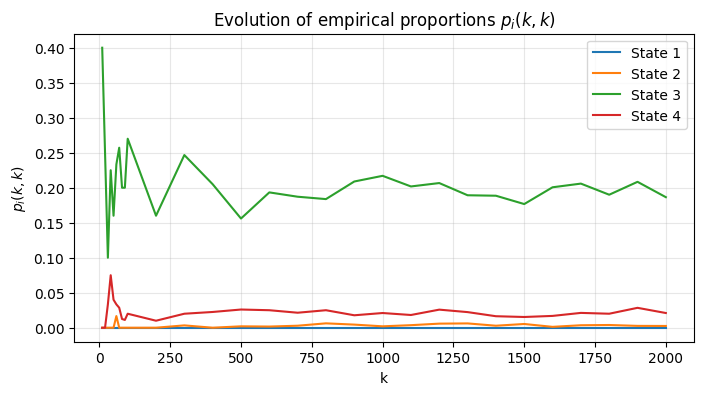

[0.     0.0025 0.1865 0.021 ]
[0.00309598 0.19504644 0.02167183 0.78018576]


In [33]:
# Definimos los parámetors iniciales de la MC
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])
m = P.shape[0]

# Definimos el "grid" de valores k que vamos a recorrer: 10, 20, 30, ... 100, 200, 300, ..., 2000
grid = np.concatenate( (np.arange(10, 101, 10),
                        np.arange(200, 2001, 100)) )

# Obtenemos p_i(k,k) para i=1,...,m y para k en el grid anterior.
# Guardamos los resultados en un array "props_plot" de shape (m, len(grid)). (Nótese que len(grid) no es más que la longitud del grid).
props_plot = np.zeros((m, len(grid)))   # (m, len(grid))
for j in range(len(grid)):
  k = grid[j]
  # Calculamos las proporciones hasta k, y nos quedamos solo con la última columna (el instante k)
  props_plot[:,j] = proporciones_empiricas_hasta_cierto_paso(k, k, P, pi_sup_1)[:, -1]


plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(grid, props_plot[i,:], label=f"State {i+1}")
plt.xlabel("k")
plt.ylabel(r"$p_i(k,k)$")
plt.title(r"Evolution of empirical proportions $p_i(k,k)$")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Mostramos por pantalla dos cosas:
# Primero, las proporciones para el último valor de k, es decir, p_i(2000,2000).
# Segundo, la distribución estacionaria de la MC.
# Según vimos en clase, lo primero debería parecerse a lo segundo para k grande. Y efectivamente vemos que es así.
# No obstante, dependiendo de la ejecución concreta, se parecerá más o menos (una cuestión interesante sería estudiar la velocidad de convergencia, que no parece ser muy elevada porque, para k=2000, aún no parece estabilizarse del todo)
print(props_plot[:,-1])
print(obtener_marginal(P, pi_sup_1, 50) )


##**5. Teorema ergódico**

En esta sección vamos a verificar empíricamente el teorema ergódico para algunas MCs.

Recuerda que el teorema ergódico se enunciaba para una función $f:S\to\mathbb{R}$ arbitraria. Aquí vamos a considerar la función indicadora $f_i$ que se comentó en la diapositiva 107. Por tanto, estaremos calculando lo que denotábamos por $q_i(n)$ en la diapositiva 106. Recuerda que $q_i(n)$ no es más que la frecuencia (o proporción) de visita al estado $i$-ésimo para una trayectoria aleatoria de la MC, es decir:


$$q_i(n) = \frac{\textrm{Cantidad de veces que se visita $i$ en los $n$ primeros pasos}}{n}$$

Como sabemos, se debe cumplir $q_i(n)\geq 0$ y $\sum_i q_i(n) = 1$.  

Vamos a empezar por definir una función que, dada una MC (```P``` y ```pi_sup_1```) y una cantidad de pasos ```n_steps```, calcule las cantidades $q_i(n)$ para cada $i=1,\dots,m$ y cada $n=1,\dots,n_{steps}$. Estos valores los devolverá en un array con shape (m, n_steps).

In [29]:
def frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1):
  """
  Función que calcula la frecuencia empírica de visitas a cada uno de los estados
  para una trayectoria de una MC hasta cierto paso.

  Input:
    n_steps: int
       Paso hasta el que queremos calcular las frecuencias. Se calcularán las frecuencias para n pasos, con n=1,2,..., n_steps.
    P: np.array (m,m)
       Matriz de transición de la MC dnd m es el número de estados.
    pi_sup_1: np.array (m,)
       Distribución inicial de la MC. Probabilidades de empezar en cada estado.

  Output:
    frecuencias_hasta_cierto_paso: np.array (m, n_steps)
       Frecuencias empíricas obtenidas, es decir el valor q_i(n) para i=1,...,m y n=1,...,n_steps.
  """

  # Guardamos el valor de m (número de estados)
  m = P.shape[0]

  # Simulamos 1 trayectoria para la MC, hasta el paso n_steps
  trayectoria = simular_trayectorias_effic(P, pi_sup_1, 1, n_steps)  # (1, n_steps)

  # Comparamos cada valor obtenido con cada uno de los m posibles estados.

  # Creamos un vector columna de estados de tamaño (m, 1) para usar el broadcasting de numpy
  estados = np.arange(m).reshape(m, 1)

  # Al comparar con el vector columna, numpy estira los datos y nos genera una matriz (m, n_steps)
  # dnd cada celda (i,j) es True si en el paso j la trayectoria visitó el estado i
  is_equal_bool = (trayectoria == estados)  # (m, n_steps)

  # Calculamos los recuentos acumulados usandp 'np.cumsum' en el axis=1 xq para
  # ir sumando por filas los elemento que están a 'True'.
  recuentos_hasta_cierto_paso = np.cumsum(is_equal_bool, axis=1)  # (m, n_steps)

  # Creamos un array lineal con los pasos transcurridos: [1, 2, ..., n_steps]
  pasos = np.arange(1, n_steps + 1)

  # Calculamos las frecuencias relativas q_i(n) dividiendo los recuentos acumulados
  # entre el número de pasos
  frecuencias_hasta_cierto_paso = recuentos_hasta_cierto_paso / pasos   # (m, n_steps)

  return frecuencias_hasta_cierto_paso    # (m, n_steps)

Vamos a usar esta función para visualizar el teorema ergódico en dos MCs que son unicadenales, y por tanto están en las hipótesis del teorema ergódico. Primero miraremos una aperiódica (y que por tanto también está en las condiciones del teorema de convergencia de MCs) y luego miraremos una periódica (y que por tanto NO está en las condiciones del teorema de convergencia de MCs).

Como unicadenal aperiódica tomamos la que hemos usado al principio de la sección 4 anterior:

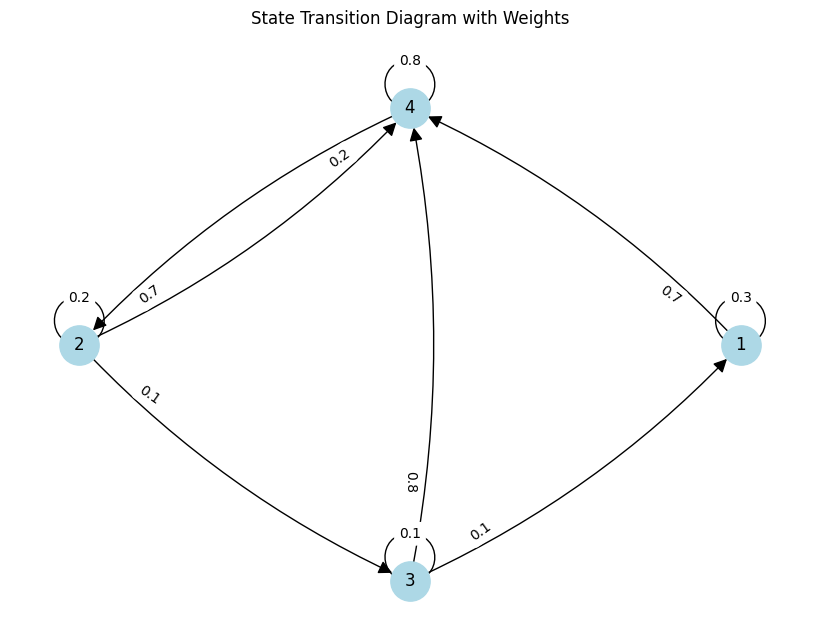

In [30]:
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
dibujar_diagrama_transicion(P, [1,2,3,4])

Recordamos de la sección 4 que la distribución estacionaria de esta MC parecía estar entorno a
$$[0.003, \; 0.195, \; 0.022, \; 0.780]$$
puesto que la marginal se estabilizaba en esos valores. Veamos que, tal y como garantiza el teorema ergódico, las cantidades $q_i(n)$ convergen a la distribución estacionaria, es decir, $q_i(n) \to (\pi)_i$ cuando $n\to\infty$.

En la siguiente celda se representa la evolución de cada una de las $q_i(n)$ cuando $n$ crece (desde $1$ hasta $10000$). Al final del todo también se imprimen por pantalla los valores de $q_i(10000)$, para poder compararlos con la distribución estacionaria.

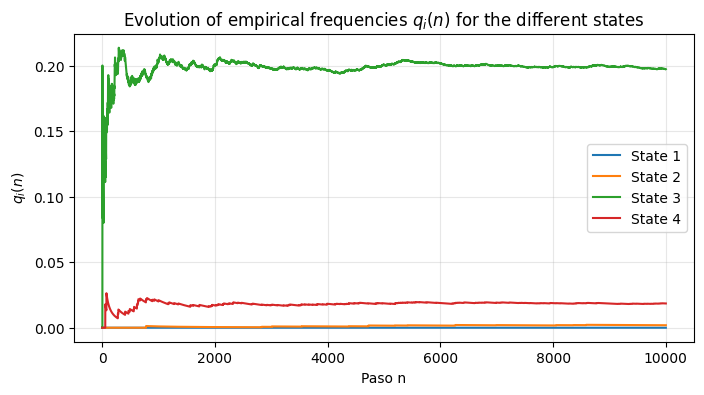

[0.     0.0019 0.1972 0.0185]


In [34]:
# Definimos los parámetros de la MC
P = np.array([[0.3,0,0,0.7],
              [0,0.2,0.1,0.7],
              [0.1,0,0.1,0.8],
              [0,0.2,0,0.8]])
pi_sup_1 = np.array([0.25, 0.25, 0.25, 0.25])
n_steps = 10000
m = P.shape[0]

# Calculamos la matriz de frecuencias acumuladas q_i(n) para los 10000 pasos
frecs = frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1)  # (m, n_steps)

plt.figure(figsize=(8, 4))
for i in range(m):
  # Para cada estado i, graficamos toda su evolución temporal (su fila correspondiente en frecs)
  plt.plot(np.arange(1, n_steps+1), frecs[i, :], label=f"State {i+1}")
plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolution of empirical frequencies $q_i(n)$ for the different states")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(frecs[:,-1])

Por último, vamos a considerar la MC periódica que vimos en la sección 4:

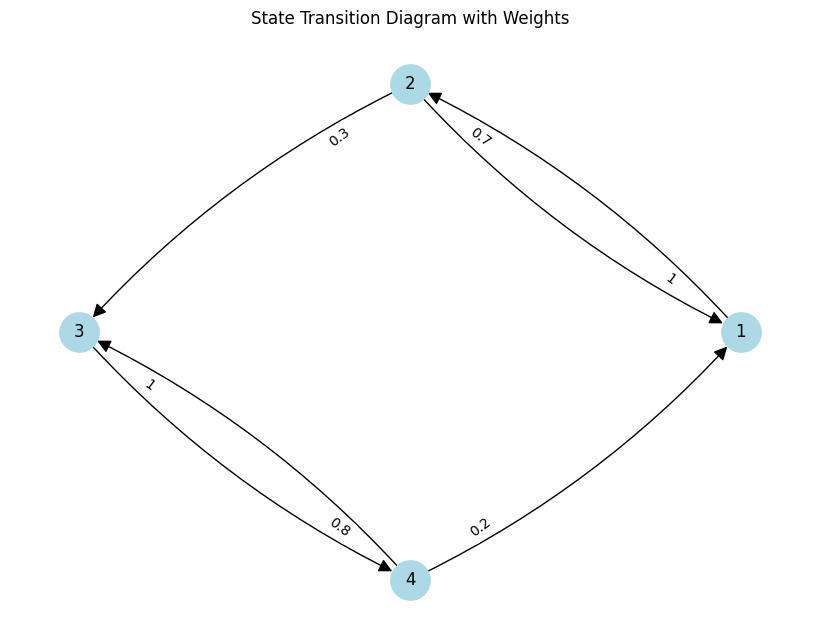

In [31]:
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
dibujar_diagrama_transicion(P, np.arange(1,P.shape[0]+1))

Vamos a seleccionar una distribución inicial ```pi_sup_1``` para la que sabemos que la distribución marginal no converge, como se vio en la sección 4. Y vamos a ver que, aunque la distribución marginal no converge, sí que se cumple el teorema ergódico, y las frecuencias a lo largo de una trayectoria sí que convergen a la distribución estacionaria. En efecto, recuerda que el teorema ergódico no requiere "aperiodicidad" (a diferencia del teorema de convergencia de MCs).

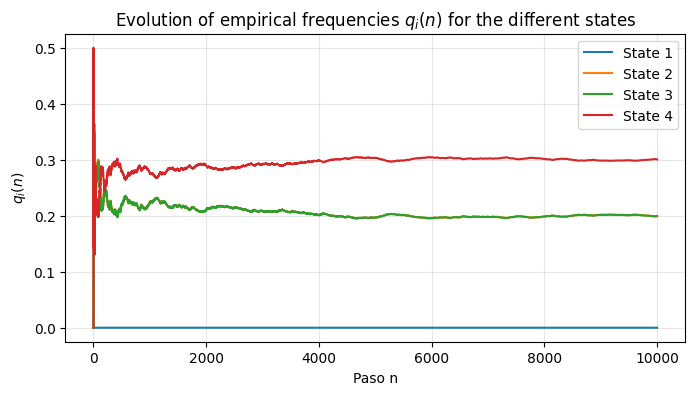

[0.     0.1995 0.1994 0.3005]


In [36]:
# Definimos la MC
P = np.array([[0.0,1.0,0.0,0.0],
              [0.7,0.0,0.3,0.0],
              [0.0,0.0,0.0,1.0],
              [0.2,0.0,0.8,0.0]])
pi_sup_1 = np.array([0.2, 0.3, 0.2, 0.3])
n_steps = 10000
m = P.shape[0]

frecs = frecuencia_empirica_hasta_cierto_paso(n_steps, P, pi_sup_1)  # (m, n_steps)

plt.figure(figsize=(8, 4))
for i in range(m):
  plt.plot(np.arange(1, n_steps+1), frecs[i, :], label=f"State {i+1}")
plt.xlabel("Paso n")
plt.ylabel(r"$q_i(n)$")
plt.title(r"Evolution of empirical frequencies $q_i(n)$ for the different states")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(frecs[:,-1])

Esto converge al valor esperado. En efecto, recuerda de la sección 4 que la única distribución estacionaria de esta MC venía dada por: [0.2, 0.2, 0.3, 0.3].

# **Referencias**

Toda la teoría, fórmulas y definiciones que he utilizado como referencia para programar estas simulaciones provienen de:
* **Morales Álvarez, P.** (*s.f.*). *Tema 2: Cadenas de Markov y Procesos de Markov* [Diapositivas de clase]. Universidad de Granada.